In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [116]:
df = pd.read_csv(r"C:\Users\sofiya.khristoforova\Downloads\Новая форма.csv", header=None, skiprows=1)

In [135]:
new_columns = ['время', 'пол', 'опыт_отношений', 'опыт_измены', 'сохранить_после_измены',
    'условия_прощения', 'разница_мужчина_женщина', 'переписка_с_бывшим',
    'ужин_с_коллегой', 'лайк_откровенное_фото', 'флирт_с_другим', 'партнер_в_клубе',
    'поцелуй_в_щеку_другу', 'секс_во_сне', 'эмоциональная_близость',
    'тайная_переписка', 'секс_с_другим', 'влюбленность_без_контакта',
    'держать_за_руку', 'нашли_флирт_в_телефоне', 'кофе_с_незнакомцем_в_командировке',
    'друг_изменяет_партнеру', 'призналась_в_измене_год_назад',
    'проверять_телефон_без_спроса']
df.columns = new_columns
df.head(5)

,время,пол,опыт_отношений,опыт_измены,сохранить_после_измены,условия_прощения,разница_мужчина_женщина,переписка_с_бывшим,ужин_с_коллегой,лайк_откровенное_фото,флирт_с_другим,партнер_в_клубе,поцелуй_в_щеку_другу,секс_во_сне,эмоциональная_близость,тайная_переписка,секс_с_другим,влюбленность_без_контакта,держать_за_руку,нашли_флирт_в_телефоне,кофе_с_незнакомцем_в_командировке,друг_изменяет_партнеру,призналась_в_измене_год_назад,проверять_телефон_без_спроса
0,2026/03/01 6:58:22 PM GMT+3,Мужской,Были отношения/в отношениях,"Да, мне изменяли;Да, я был(а) ""третьим"" лицом",Нет,Деятельное раскаяние: изменивший партнёр работ...,Да,1,0,2,3,1,1,1,2,3,3,3,2,"Посмотрю, как развиваются события","Откажусь, даже если никто не узнает — это вопр...",Намекну его/ее партнёру,"Да, правда любой ценой","Нет, это нарушение границ"
1,2026/03/01 7:37:45 PM GMT+3,Женский,Не было отношений,"Нет, не сталкивался(лась)",Нет,"Нет, не простил(а) бы",Нет,1,0,1,2,2,1,2,2,3,3,3,0,"Поговорю с партнером, после решу, что делать","Пойду, это же просто кофе","Промолчу, не моё дело","Да, правда любой ценой","Нет, это нарушение границ"
2,2026/03/01 7:39:15 PM GMT+3,Женский,Были отношения/в отношениях,"Нет, не сталкивался(лась)",Нет,"Нет, не простил(а) бы",Нет,1,1,0,3,2,1,1,0,2,3,3,2,Уйду без разговоров,"Откажусь, даже если никто не узнает — это вопр...",Осужу и потребую признаться,"Да, правда любой ценой","Нет, это нарушение границ"
3,2026/03/01 7:39:41 PM GMT+3,Женский,Были отношения/в отношениях,"Да, я был(а) ""третьим"" лицом",Нет,"Нет, не простил(а) бы",Нет,3,2,2,2,2,2,0,3,2,3,3,3,"Поговорю с партнером, после решу, что делать","Откажусь, даже если никто не узнает — это вопр...",Осужу и потребую признаться,"Да, правда любой ценой","Нет, это нарушение границ"
4,2026/03/01 7:44:21 PM GMT+3,Мужской,Не было отношений,"Нет, не сталкивался(лась)",Нет,"Нет, не простил(а) бы",Нет,2,1,2,2,1,1,2,3,2,3,2,0,Уйду без разговоров,"Откажусь, даже если никто не узнает — это вопр...","Промолчу, не моё дело",Зависит от деталей,"Нет, это нарушение границ"


Text(0.5, 0, 'Пол')

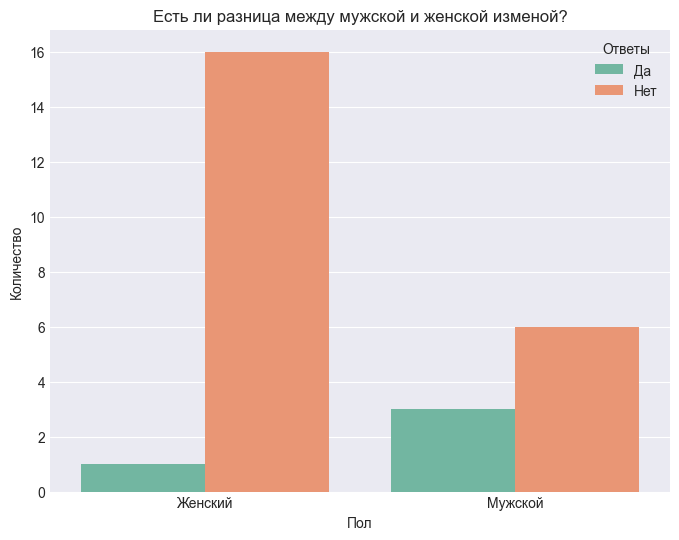

In [122]:
difference = df[['пол', 'разница_мужчина_женщина']]
difference.head(5)
cnt = difference.groupby(['пол', 'разница_мужчина_женщина']).size().reset_index(name='cnt')
cnt = cnt.rename(columns={'разница_мужчина_женщина': 'Ответы'})

plt.figure(figsize=(8, 6))
sns.barplot(data=cnt, x='пол', y='cnt', hue='Ответы')
plt.title('Есть ли разница между мужской и женской изменой?')
plt.ylabel('Количество')
plt.xlabel('Пол')

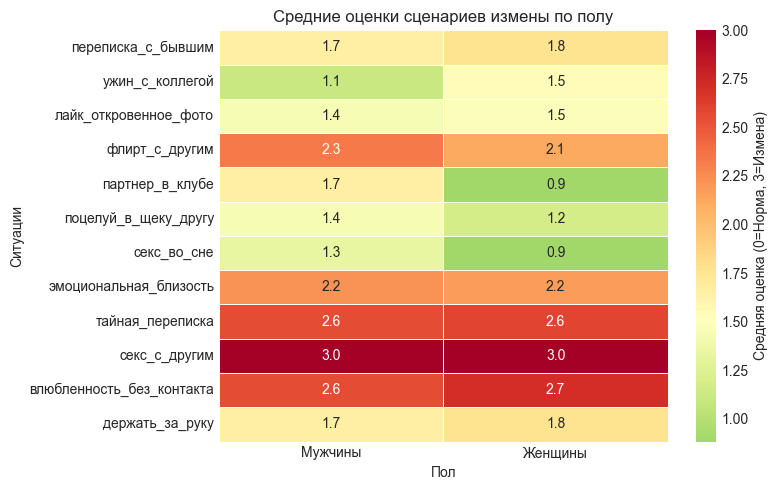

In [153]:
rating = {'Норма': 0, 'Странно': 1, 'Неприятно': 2, 'Измена': 3}
sit_col = ['переписка_с_бывшим', 'ужин_с_коллегой', 'лайк_откровенное_фото', 
                   'флирт_с_другим', 'партнер_в_клубе', 'поцелуй_в_щеку_другу',
                   'секс_во_сне', 'эмоциональная_близость', 'тайная_переписка',
                   'секс_с_другим', 'влюбленность_без_контакта', 'держать_за_руку']

for el in sit_col:
    df[el] = df[el].replace(rating).astype(int)
df_m = df[df['пол'] == 'Мужской'][sit_col].mean()
df_w = df[df['пол'] == 'Женский'][sit_col].mean()

heatmap_data_s = pd.DataFrame({'Мужчины': df_m, 'Женщины': df_w})

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data_s, annot=True, cmap='RdYlGn_r', center=1.5, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Средняя оценка (0=Норма, 3=Измена)'})
plt.title('Средние оценки сценариев измены по полу')
plt.xlabel('Пол')
plt.ylabel('Ситуации')
plt.xticks()
plt.yticks()
plt.tight_layout()
plt.show()

In [126]:
heatmap_data_s['дельта'] = heatmap_data_s['Мужчины'] - heatmap_data_s['Женщины']
heatmap_data_s.sort_values(by=["дельта"], ascending = False)

,Мужчины,Женщины,дельта
партнер_в_клубе,1.666667,0.882353,0.784314
секс_во_сне,1.333333,0.882353,0.450980
поцелуй_в_щеку_другу,1.444444,1.176471,0.267974
флирт_с_другим,2.333333,2.117647,0.215686
эмоциональная_близость,2.222222,2.176471,0.045752
секс_с_другим,3.000000,3.000000,0.000000
лайк_откровенное_фото,1.444444,1.470588,-0.026144
тайная_переписка,2.555556,2.588235,-0.032680
держать_за_руку,1.666667,1.764706,-0.098039
переписка_с_бывшим,1.666667,1.764706,-0.098039


# Выводы

---

## КЛЮЧЕВЫЕ ВЫВОДЫ

### 1. СИТУАЦИИ, ГДЕ МУЖЧИНЫ СЧИТАЮТ БОЛЕЕ СЕРЬЕЗНЫМ (дельта положительная)

| Ситуация | Мужчины | Женщины | Дельта | Интерпретация |
|----------|---------|---------|--------|---------------|
| **партнер_в_клубе** | 1.67 | 0.88 | **+0.78** |  **ЗНАЧИМОЕ РАЗЛИЧИЕ**: Мужчины видят это ближе к "странно", женщины ближе к "норма" |
| **секс_во_сне** | 1.33 | 0.88 | **+0.45** |  **ЗНАЧИМОЕ РАЗЛИЧИЕ**: Мужчины относятся более настороженно |
| поцелуй_в_щеку_другу | 1.44 | 1.18 | +0.27 | Незначимо |
| флирт_с_другим | 2.33 | 2.12 | +0.22 | Незначимо |

### 2. СИТУАЦИИ, ГДЕ ЖЕНЩИНЫ СЧИТАЮТ БОЛЕЕ СЕРЬЕЗНЫМ (дельта отрицательная)

| Ситуация | Мужчины | Женщины | Дельта | Интерпретация |
|----------|---------|---------|--------|---------------|
| **ужин_с_коллегой** | 1.11 | 1.53 | **-0.42** | **ЗНАЧИМОЕ РАЗЛИЧИЕ**: Женщины видят это ближе к "странно", мужчины ближе к "норма" |
| влюбленность_без_контакта | 2.56 | 2.71 | -0.15 | Незначимо |
| переписка_с_бывшим | 1.67 | 1.76 | -0.10 | Незначимо |
| держать_за_руку | 1.67 | 1.76 | -0.10 | Незначимо |

### 3. СИТУАЦИИ БЕЗ РАЗЛИЧИЙ

| Ситуация | Мужчины | Женщины | Дельта |
|----------|---------|---------|--------|
| секс_с_другим | 3.00 | 3.00 | 0.00 |

---

## ГЛАВНЫЕ ВЫВОДЫ

### **Что мужчины воспринимают серьезнее женщин:**
1. **Партнер в клубе** (+0.78) - **самое большое различие** в таблице
   - *Мужчины оценивают как "странно" (1.67), женщины как "норма" (0.88)*
2. **Секс во сне** (+0.45) - значимое различие
   - *Мужчины ближе к "странно", женщины ближе к "норма"*

### **Что женщины воспринимают серьезнее мужчин:**
1. **Ужин с коллегой** (-0.42) - единственное значимое различие в пользу женщин
   - *Женщины видят это как "странно" (1.53), мужчины как "норма" (1.11)*

---

## ИНТЕРЕСНЫЕ НАБЛЮДЕНИЯ

- **Секс с другим** - абсолютный консенсус (3.0 у обоих полов) - **все считают это изменой**
- **Эмоциональная близость** - практически одинаковое восприятие (2.22 vs 2.18)
- **Наибольшее несогласие** - ситуация "партнер в клубе" (разрыв в **0.78** пункта)
- **7 из 12 ситуаций** имеют минимальные различия (< 0.2) - мнения совпадают

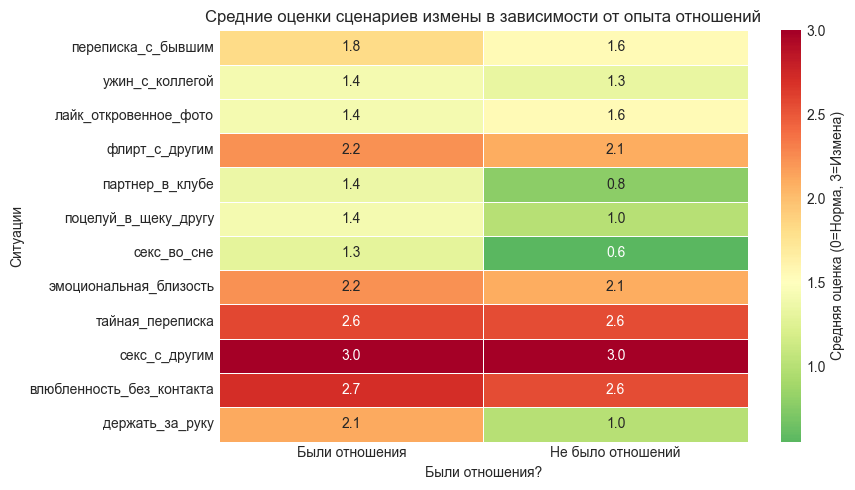

In [151]:
df_relsh = df[df['опыт_отношений'] == 'Были отношения/в отношениях'][sit_col].mean()
df_no_relsh = df[df['опыт_отношений'] == 'Не было отношений'][sit_col].mean()

heatmap_data_rel = pd.DataFrame({'Были отношения': df_relsh, 'Не было отношений': df_no_relsh})
plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data_rel, annot=True, cmap='RdYlGn_r', center=1.5, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Средняя оценка (0=Норма, 3=Измена)'})
plt.title('Средние оценки сценариев измены в зависимости от опыта отношений')
plt.xlabel('Были отношения?')
plt.ylabel('Ситуации')
plt.xticks()
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

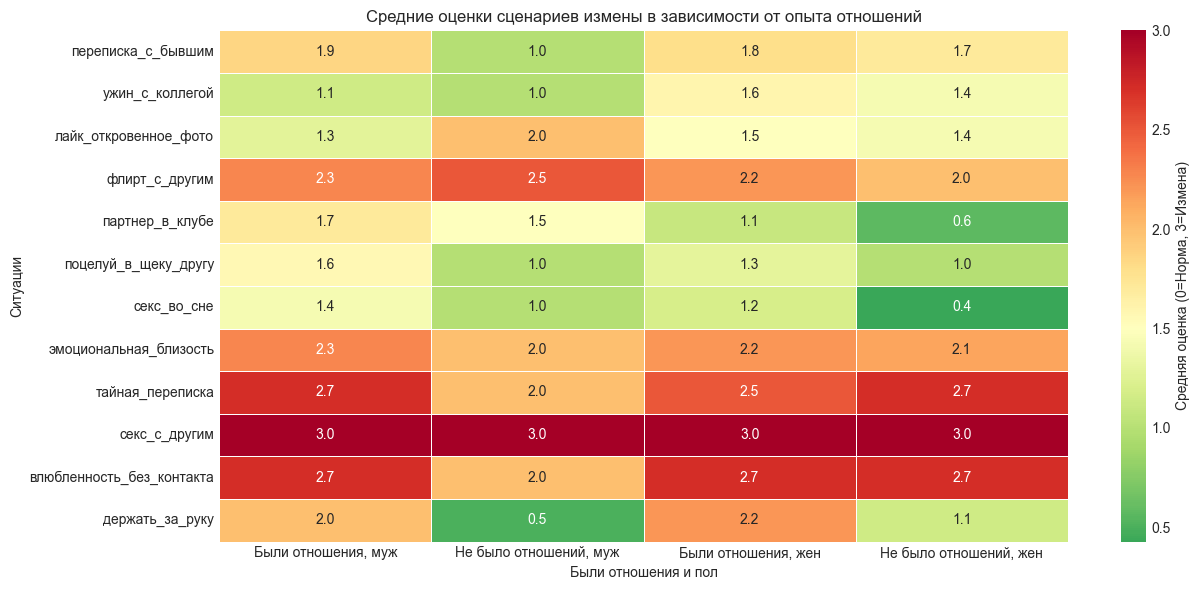

In [148]:
df_relsh_w = df[(df['опыт_отношений'] == 'Были отношения/в отношениях') & (df['пол'] == 'Женский')][sit_col].mean()
df_no_relsh_w = df[(df['опыт_отношений'] == 'Не было отношений') & (df['пол'] == 'Женский')][sit_col].mean()

df_relsh_m = df[(df['опыт_отношений'] == 'Были отношения/в отношениях') & (df['пол'] == 'Мужской')][sit_col].mean()
df_no_relsh_m = df[(df['опыт_отношений'] == 'Не было отношений') & (df['пол'] == 'Мужской')][sit_col].mean()


heatmap_data_rel = pd.DataFrame({'Были отношения, муж': df_relsh_m, 'Не было отношений, муж': df_no_relsh_m,
                                'Были отношения, жен': df_relsh_w, 'Не было отношений, жен': df_no_relsh_w})
plt.figure(figsize=(13, 6))
sns.heatmap(heatmap_data_rel, annot=True, cmap='RdYlGn_r', center=1.5, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Средняя оценка (0=Норма, 3=Измена)'})
plt.title('Средние оценки сценариев измены в зависимости от опыта отношений')
plt.xlabel('Были отношения и пол')
plt.ylabel('Ситуации')
plt.xticks()
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

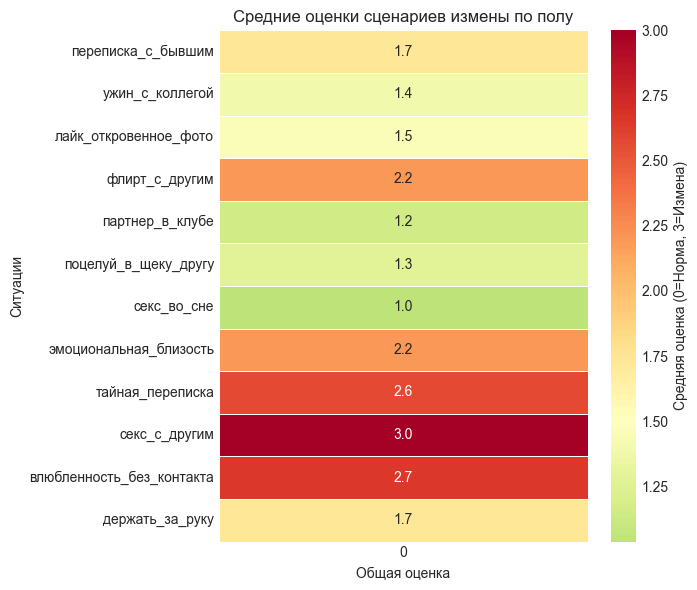

In [146]:
df_all = pd.DataFrame(df[sit_col].mean())
plt.figure(figsize=(7, 6))
sns.heatmap(df_all, cmap='RdYlGn_r', center=1.5, fmt='.1f', annot=True,
            linewidths=0.5, cbar_kws={'label': 'Средняя оценка (0=Норма, 3=Измена)'})
plt.title('Средние оценки сценариев измены по полу')
plt.xlabel('Общая оценка')
plt.ylabel('Ситуации')
plt.yticks()
plt.tight_layout()
plt.show()

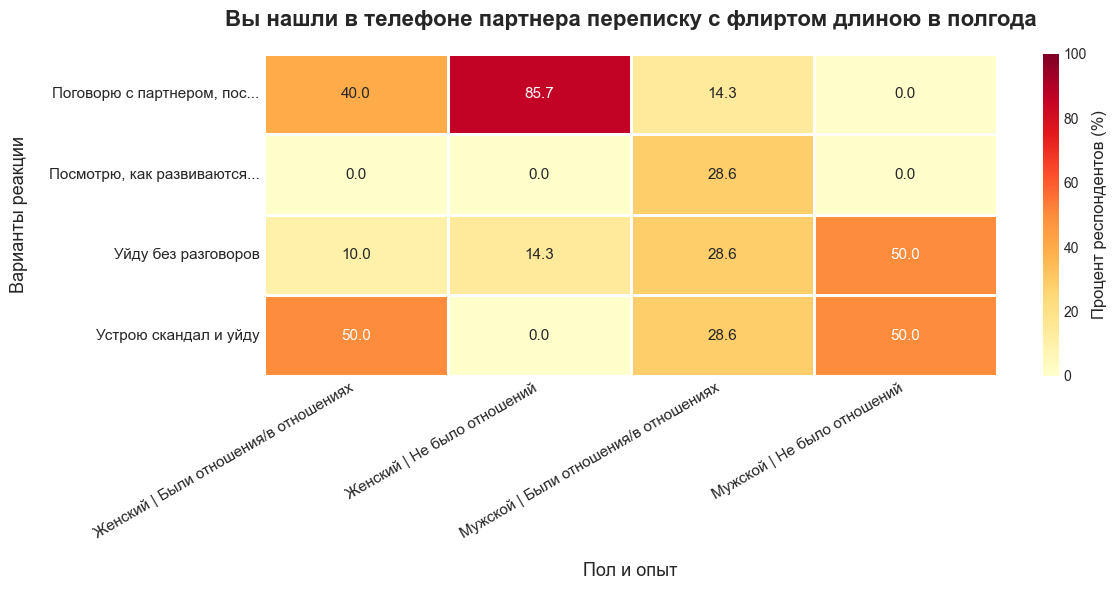

In [159]:
fig, ax = plt.subplots(figsize=(12, 6))
pivot = pd.crosstab([df['пол'], df['опыт_отношений']], df['нашли_флирт_в_телефоне'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.index = [f"{gender} | {exp}" for gender, exp in pivot_pct.index]


def shorten_text(text, max_length=25):
    if len(text) > max_length:
        return text[:max_length] + '...'
    return text

pivot_pct.columns = [shorten_text(col) for col in pivot_pct.columns]


sns.heatmap(pivot_pct.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Процент респондентов (%)'},
            ax=ax, linewidths=2,linecolor='white', annot_kws={'size': 11},square=False,vmin=0, vmax=100)

ax.set_title('Вы нашли в телефоне партнера переписку с флиртом длиною в полгода', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Пол и опыт', fontsize=13, labelpad=15)
ax.set_ylabel('Варианты реакции', fontsize=13, labelpad=15)


plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Процент респондентов (%)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

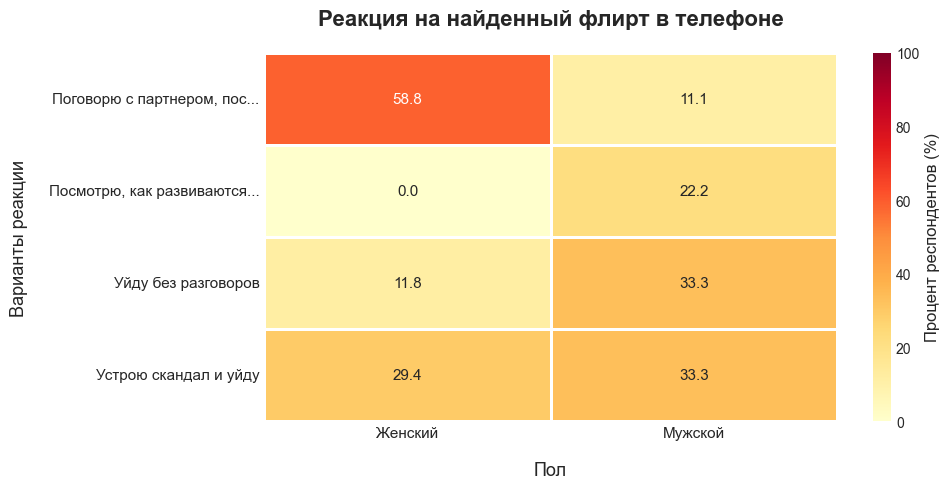

In [160]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot = pd.crosstab(df['пол'], df['нашли_флирт_в_телефоне'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100



def shorten_text(text, max_length=25):
    if len(text) > max_length:
        return text[:max_length] + '...'
    return text

pivot_pct.columns = [shorten_text(col) for col in pivot_pct.columns]


sns.heatmap(pivot_pct.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Процент респондентов (%)'},
            ax=ax, linewidths=2,linecolor='white', annot_kws={'size': 11},square=False,vmin=0, vmax=100)

ax.set_title('Реакция на найденный флирт в телефоне', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Пол', fontsize=13, labelpad=15)
ax.set_ylabel('Варианты реакции', fontsize=13, labelpad=15)


plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Процент респондентов (%)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

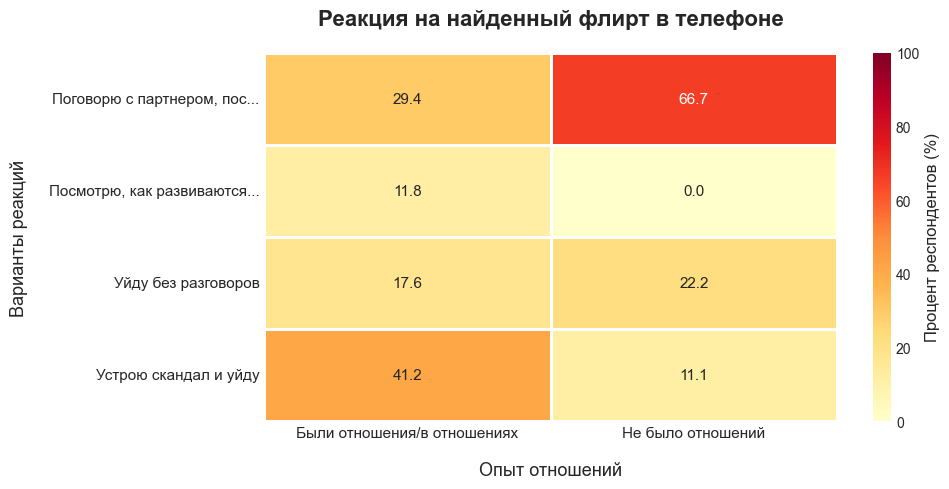

In [165]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot = pd.crosstab(df['опыт_отношений'], df['нашли_флирт_в_телефоне'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100



def shorten_text(text, max_length=25):
    if len(text) > max_length:
        return text[:max_length] + '...'
    return text

pivot_pct.columns = [shorten_text(col) for col in pivot_pct.columns]


sns.heatmap(pivot_pct.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Процент респондентов (%)'},
            ax=ax, linewidths=2,linecolor='white', annot_kws={'size': 11},square=False,vmin=0, vmax=100)

ax.set_title('Реакция на найденный флирт в телефоне', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Опыт отношений', fontsize=13, labelpad=15)
ax.set_ylabel('Варианты реакций', fontsize=13, labelpad=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Процент респондентов (%)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

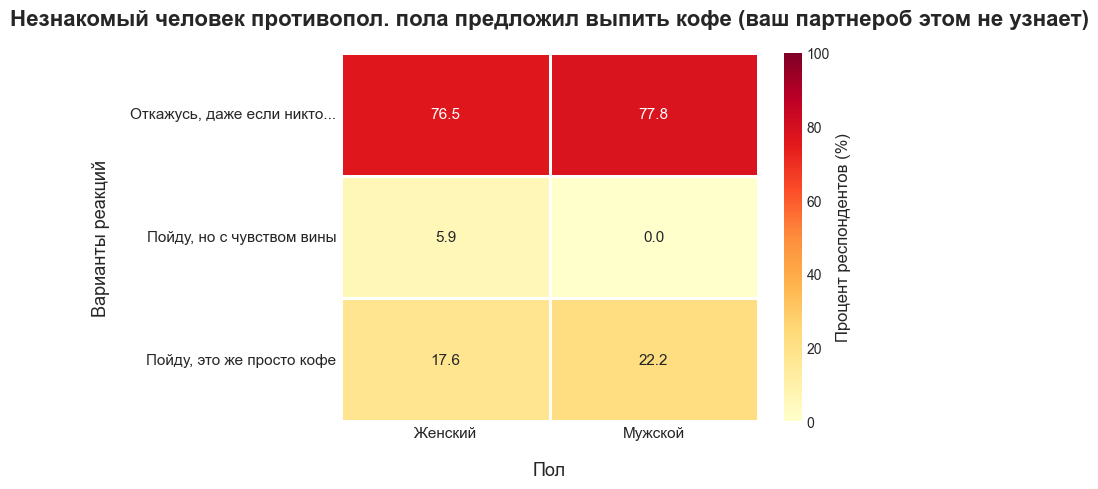

In [167]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = pd.crosstab(df['пол'], df['кофе_с_незнакомцем_в_командировке'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100



def shorten_text(text, max_length=25):
    if len(text) > max_length:
        return text[:max_length] + '...'
    return text

pivot_pct.columns = [shorten_text(col) for col in pivot_pct.columns]


sns.heatmap(pivot_pct.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Процент респондентов (%)'},
            ax=ax, linewidths=2,linecolor='white', annot_kws={'size': 11},square=False,vmin=0, vmax=100)

ax.set_title('Незнакомый человек противопол. пола предложил выпить кофе (ваш партнероб этом не узнает)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Пол', fontsize=13, labelpad=15)
ax.set_ylabel('Варианты реакций', fontsize=13, labelpad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Процент респондентов (%)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

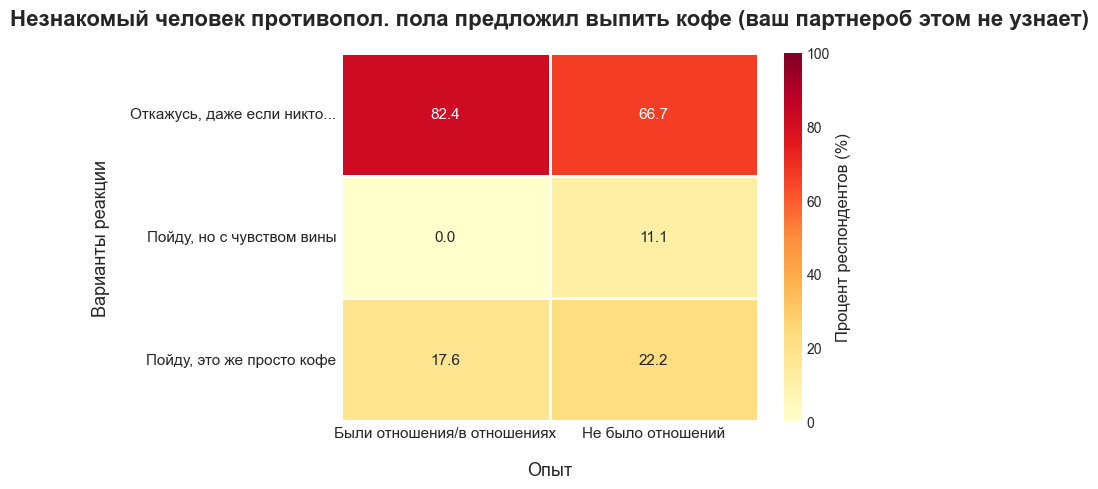

In [168]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = pd.crosstab(df['опыт_отношений'], df['кофе_с_незнакомцем_в_командировке'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100



def shorten_text(text, max_length=25):
    if len(text) > max_length:
        return text[:max_length] + '...'
    return text

pivot_pct.columns = [shorten_text(col) for col in pivot_pct.columns]


sns.heatmap(pivot_pct.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Процент респондентов (%)'},
            ax=ax, linewidths=2,linecolor='white', annot_kws={'size': 11},square=False,vmin=0, vmax=100)

ax.set_title('Незнакомый человек противопол. пола предложил выпить кофе (ваш партнероб этом не узнает)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Опыт', fontsize=13, labelpad=15)
ax.set_ylabel('Варианты реакции', fontsize=13, labelpad=15)


plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Процент респондентов (%)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

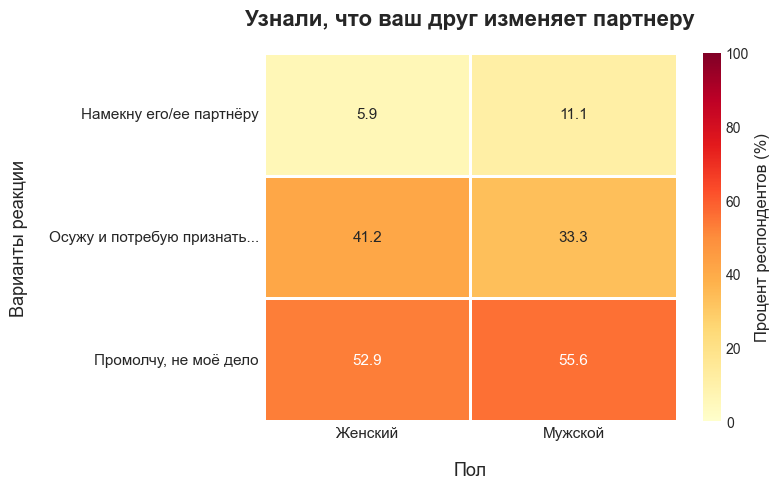

In [169]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = pd.crosstab(df['пол'], df['друг_изменяет_партнеру'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100



def shorten_text(text, max_length=25):
    if len(text) > max_length:
        return text[:max_length] + '...'
    return text

pivot_pct.columns = [shorten_text(col) for col in pivot_pct.columns]


sns.heatmap(pivot_pct.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Процент респондентов (%)'},
            ax=ax, linewidths=2,linecolor='white', annot_kws={'size': 11},square=False,vmin=0, vmax=100)

ax.set_title('Узнали, что ваш друг изменяет партнеру', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Пол', fontsize=13, labelpad=15)
ax.set_ylabel('Варианты реакции', fontsize=13, labelpad=15)


plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Процент респондентов (%)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

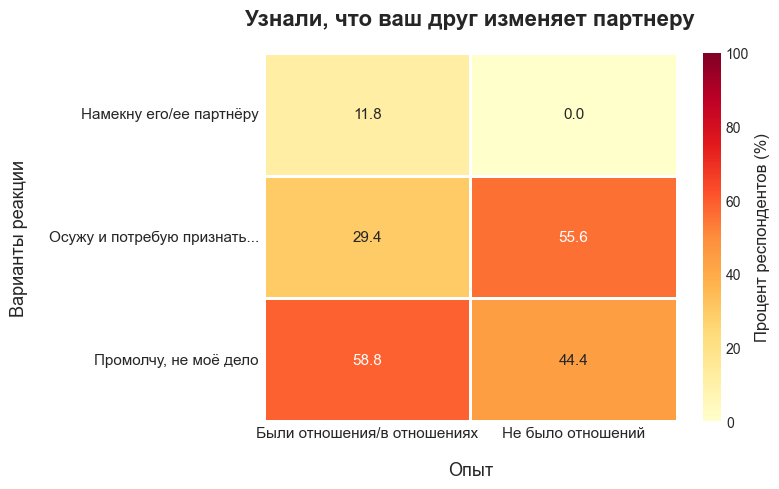

In [170]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = pd.crosstab(df['опыт_отношений'], df['друг_изменяет_партнеру'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100



def shorten_text(text, max_length=25):
    if len(text) > max_length:
        return text[:max_length] + '...'
    return text

pivot_pct.columns = [shorten_text(col) for col in pivot_pct.columns]


sns.heatmap(pivot_pct.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Процент респондентов (%)'},
            ax=ax, linewidths=2,linecolor='white', annot_kws={'size': 11},square=False,vmin=0, vmax=100)

ax.set_title('Узнали, что ваш друг изменяет партнеру', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Опыт', fontsize=13, labelpad=15)
ax.set_ylabel('Варианты реакции', fontsize=13, labelpad=15)


plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Процент респондентов (%)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

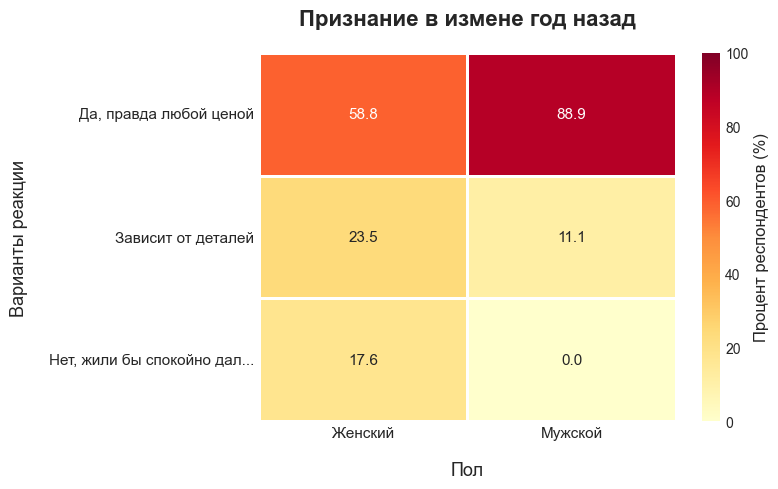

In [171]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = pd.crosstab(df['пол'], df['призналась_в_измене_год_назад'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100



def shorten_text(text, max_length=25):
    if len(text) > max_length:
        return text[:max_length] + '...'
    return text

pivot_pct.columns = [shorten_text(col) for col in pivot_pct.columns]


sns.heatmap(pivot_pct.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Процент респондентов (%)'},
            ax=ax, linewidths=2,linecolor='white', annot_kws={'size': 11},square=False,vmin=0, vmax=100)

ax.set_title('Признание в измене год назад', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Пол', fontsize=13, labelpad=15)
ax.set_ylabel('Варианты реакции', fontsize=13, labelpad=15)


plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Процент респондентов (%)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

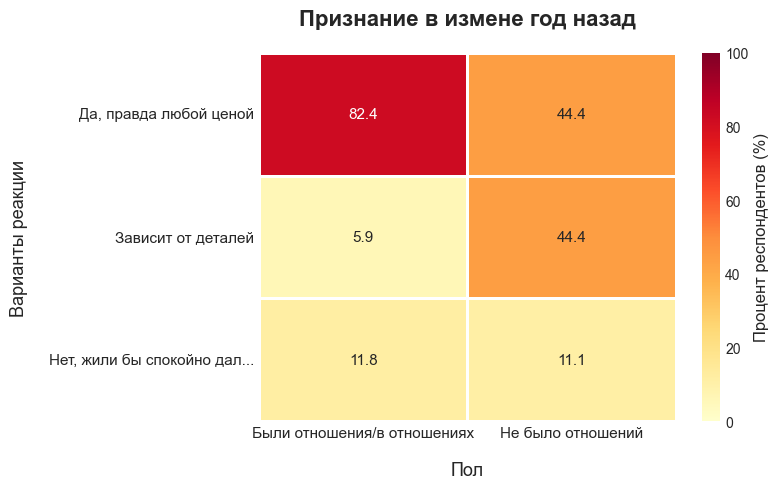

In [172]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = pd.crosstab(df['опыт_отношений'], df['призналась_в_измене_год_назад'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100



def shorten_text(text, max_length=25):
    if len(text) > max_length:
        return text[:max_length] + '...'
    return text

pivot_pct.columns = [shorten_text(col) for col in pivot_pct.columns]


sns.heatmap(pivot_pct.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Процент респондентов (%)'},
            ax=ax, linewidths=2,linecolor='white', annot_kws={'size': 11},square=False,vmin=0, vmax=100)

ax.set_title('Признание в измене год назад', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Пол', fontsize=13, labelpad=15)
ax.set_ylabel('Варианты реакции', fontsize=13, labelpad=15)


plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Процент респондентов (%)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

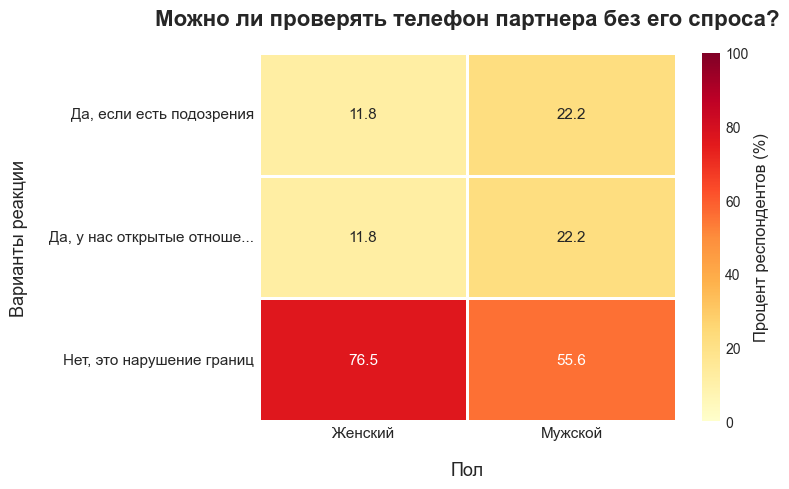

In [173]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = pd.crosstab(df['пол'], df['проверять_телефон_без_спроса'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100



def shorten_text(text, max_length=25):
    if len(text) > max_length:
        return text[:max_length] + '...'
    return text

pivot_pct.columns = [shorten_text(col) for col in pivot_pct.columns]


sns.heatmap(pivot_pct.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Процент респондентов (%)'},
            ax=ax, linewidths=2,linecolor='white', annot_kws={'size': 11},square=False,vmin=0, vmax=100)

ax.set_title('Можно ли проверять телефон партнера без его спроса?', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Пол', fontsize=13, labelpad=15)
ax.set_ylabel('Варианты реакции', fontsize=13, labelpad=15)


plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Процент респондентов (%)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

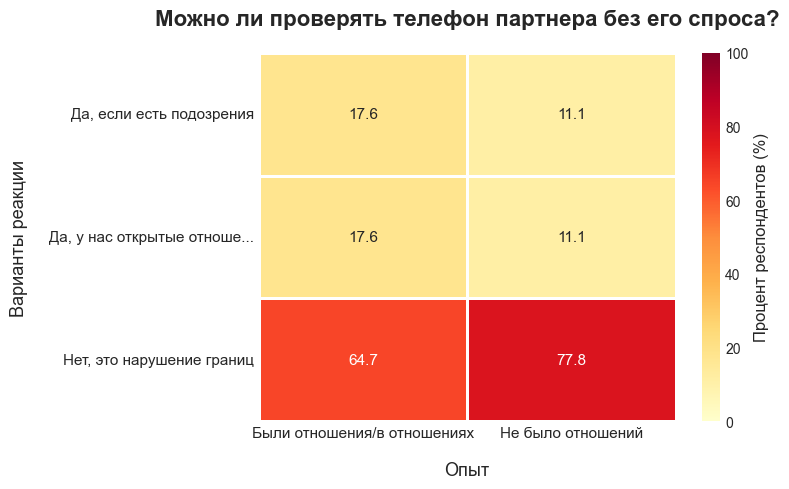

In [175]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = pd.crosstab(df['опыт_отношений'], df['проверять_телефон_без_спроса'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100



def shorten_text(text, max_length=25):
    if len(text) > max_length:
        return text[:max_length] + '...'
    return text

pivot_pct.columns = [shorten_text(col) for col in pivot_pct.columns]


sns.heatmap(pivot_pct.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Процент респондентов (%)'},
            ax=ax, linewidths=2,linecolor='white', annot_kws={'size': 11},square=False,vmin=0, vmax=100)

ax.set_title('Можно ли проверять телефон партнера без его спроса?', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Опыт', fontsize=13, labelpad=15)
ax.set_ylabel('Варианты реакции', fontsize=13, labelpad=15)


plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Процент респондентов (%)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()